# Case A — Sales Projection & Expansion Analysis (Booze 'R' Us)

**Client:** Booze 'R' Us — wants (1) projected sales for the coming year and
(2) guidance on expansion / sales-tactic decisions.

This notebook picks up **after** the data build step — it assumes
`liquor_category_month_agg_casea.parquet` already exists (run
`casea_build_data.ipynb` first if it doesn't, or if the raw data changed).
Nothing here re-aggregates or re-fetches external data.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import holidays

df = pd.read_parquet("liquor_category_month_agg_casea.parquet")
print(df.shape)
df.head()


(2572, 28)


,category_code,category_name,year_month,year,month_num,units,dollars,liters,n_line_items,n_bad_units,...,total_precip_anomaly_in,n_holidays,has_july4,has_thanksgiving,has_christmas,has_new_year,iowa_population,iowa_median_household_income,log_units,log_dollars
0,1022200,100% AGAVE TEQUILA,2022-01,2022,1,50549.0,1443274.89,34750.75,5596,0.0,...,-0.582902,2.0,0.0,0.0,0.0,1.0,3188836,70571,10.830718,14.182426
1,1062300,AGED DARK RUM,2022-01,2022,1,3840.0,79755.80,3004.00,674,0.0,...,-0.582902,2.0,0.0,0.0,0.0,1.0,3188836,70571,8.253488,11.286737
2,1051100,AMERICAN BRANDIES,2022-01,2022,1,61714.0,407451.14,32754.75,5407,0.0,...,-0.582902,2.0,0.0,0.0,0.0,1.0,3188836,70571,11.030282,12.917679
3,1081300,AMERICAN CORDIALS & LIQUEURS,2022-01,2022,1,35966.0,282952.50,17391.38,4327,0.0,...,-0.582902,2.0,0.0,0.0,0.0,1.0,3188836,70571,10.490357,12.553038
4,1091000,AMERICAN DISTILLED SPIRITS SPECIALTY,2022-01,2022,1,48.0,1539.00,36.00,7,0.0,...,-0.582902,2.0,0.0,0.0,0.0,1.0,3188836,70571,3.891820,7.339538


## Build the design matrix

Same dummy-encoding convention as Case B: category and month as fixed
effects, plus the linear trend `t`. Drops the same blank-category
situation (already handled in the build notebook, so this is just a
sanity check here).


In [2]:
assert (df["category_name"].str.strip() == "").sum() == 0, "blank categories should already be dropped by the build notebook"

model_df = pd.get_dummies(
    df,
    columns=["month_num", "category_name"],
    drop_first=True,
)

category_dummy_cols = [c for c in model_df.columns if c.startswith("category_name_")]
month_dummy_cols = [c for c in model_df.columns if c.startswith("month_num_")]

print(model_df.shape)
model_df.head()


(2572, 87)


,category_code,year_month,year,units,dollars,liters,n_line_items,n_bad_units,is_partial_first_year,quarter,...,category_name_SINGLE MALT SCOTCH,category_name_SPECIAL ORDER ITEMS,category_name_SPICED RUM,category_name_STRAIGHT BOURBON WHISKIES,category_name_STRAIGHT RYE WHISKIES,category_name_TEMPORARY & SPECIALTY PACKAGES,category_name_TENNESSEE WHISKIES,category_name_TRIPLE SEC,category_name_WHISKEY LIQUEUR,category_name_WHITE RUM
0,1022200,2022-01,2022,50549.0,1443274.89,34750.75,5596,0.0,True,1,...,False,False,False,False,False,False,False,False,False,False
1,1062300,2022-01,2022,3840.0,79755.80,3004.00,674,0.0,True,1,...,False,False,False,False,False,False,False,False,False,False
2,1051100,2022-01,2022,61714.0,407451.14,32754.75,5407,0.0,True,1,...,False,False,False,False,False,False,False,False,False,False
3,1081300,2022-01,2022,35966.0,282952.50,17391.38,4327,0.0,True,1,...,False,False,False,False,False,False,False,False,False,False
4,1091000,2022-01,2022,48.0,1539.00,36.00,7,0.0,True,1,...,False,False,False,False,False,False,False,False,False,False


### Model A — baseline: trend + seasonality + category only

What could Booze 'R' Us already project from nothing but a calendar and
last year's category mix? This is the floor any external data needs to
beat.


In [3]:
feature_cols_baseline = ["t"] + month_dummy_cols + category_dummy_cols
X_baseline = sm.add_constant(model_df[feature_cols_baseline].astype(float))
y = model_df["log_units"].astype(float)

model_baseline = sm.OLS(y, X_baseline, missing="drop").fit()
print(model_baseline.summary())


                            OLS Regression Results                            
Dep. Variable:              log_units   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.672
Method:                 Least Squares   F-statistic:                     86.15
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:51:12   Log-Likelihood:                -3971.2
No. Observations:                2572   AIC:                             8068.
Df Residuals:                    2509   BIC:                             8437.
Df Model:                          62                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

### Model B — + weather, holidays, demographics

Adds the three external data sources from the proposal (weather stays as
raw levels — see the design note at the top). This is the model actually
meant to produce next year's projection, since it can respond to expected
holiday timing and typical seasonal weather rather than just "which month
number is it."


In [4]:
feature_cols_full = (
    ["t", "avg_max_temp_f", "total_precip_in",
     "n_holidays", "has_july4", "has_thanksgiving", "has_christmas", "has_new_year",
     "iowa_population", "iowa_median_household_income"]
    + month_dummy_cols + category_dummy_cols
)
X_full = sm.add_constant(model_df[feature_cols_full].astype(float))

model_full = sm.OLS(y, X_full, missing="drop").fit()
print(model_full.summary())


                            OLS Regression Results                            
Dep. Variable:              log_units   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     80.32
Date:                Sat, 12 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:51:12   Log-Likelihood:                -3962.8
No. Observations:                2572   AIC:                             8062.
Df Residuals:                    2504   BIC:                             8460.
Df Model:                          67                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [5]:
comparison = pd.DataFrame({
    "Model A (baseline: trend + month + category)": {
        "adj. R-squared": model_baseline.rsquared_adj,
        "AIC": model_baseline.aic,
        "BIC": model_baseline.bic,
    },
    "Model B (+ weather/holidays/demographics)": {
        "adj. R-squared": model_full.rsquared_adj,
        "AIC": model_full.aic,
        "BIC": model_full.bic,
    },
})
comparison


,Model A (baseline: trend + month + category),Model B (+ weather/holidays/demographics)
adj. R-squared,0.672495,0.673968
AIC,8068.357163,8061.636612
BIC,8437.060825,8459.602470


## Which categories respond most to the external factors?

Rather than one national coefficient, this is the "adjust sales tactics"
part of the client's ask: are there specific categories worth promoting
around holidays, or that move with local income growth (e.g. premium
spirits vs. value categories)?


In [6]:
category_holiday_corr = (
    df.groupby("category_name")[["log_units", "n_holidays"]]
    .apply(lambda g: g["log_units"].corr(g["n_holidays"]) if len(g) > 5 else np.nan)
    .dropna()
    .sort_values(ascending=False)
)

category_income_corr = (
    df.groupby("category_name")[["log_units", "iowa_median_household_income"]]
    .apply(lambda g: g["log_units"].corr(g["iowa_median_household_income"]) if len(g) > 5 else np.nan)
    .dropna()
    .sort_values(ascending=False)
)

print("Most holiday-sensitive categories:")
print(category_holiday_corr.head(10))
print()
print("Most income-sensitive categories (candidates for higher-income expansion targets):")
print(category_income_corr.head(10))


Most holiday-sensitive categories:
category_name
IRISH WHISKIES                         0.219280
CREAM LIQUEURS                         0.215135
SINGLE MALT SCOTCH                     0.198703
COFFEE LIQUEURS                        0.198280
AMERICAN BRANDIES                      0.161454
AGED DARK RUM                          0.141881
IMPORTED DISTILLED SPIRIT SPECIALTY    0.139873
AMERICAN SLOE GINS                     0.128499
NEUTRAL GRAIN SPIRITS                  0.124956
CANADIAN WHISKIES                      0.118124
dtype: float64

Most income-sensitive categories (candidates for higher-income expansion targets):
category_name
FLAVORED GIN                            0.454242
AMERICAN DISTILLED SPIRITS SPECIALTY    0.416028
AMERICAN SCHNAPPS                       0.404886
BOTTLED IN BOND BOURBON                 0.369634
COCKTAILS/RTD                           0.344311
TEMPORARY & SPECIALTY PACKAGES          0.304754
AMERICAN VODKAS                         0.301628
100% AGAVE TEQU

c:\Users\jakea\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\jakea\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## Model evaluation

Same rigor checklist as Case B, adapted for a forecasting goal rather than
a hypothesis test:

1. Does the external data (weather/holidays/demographics) earn its place
   over the baseline (nested F-test)?
2. Do OLS's assumptions hold well enough to trust the model (residual
   diagnostics)?
3. Any problematic multicollinearity worth flagging (VIF) — expected to be
   higher here than in Case B, since we deliberately kept raw weather
   levels; the question is whether it's *bad enough* to hurt prediction,
   not whether it exists at all.
4. Does it generalize to months it hasn't seen (time-based holdout) — this
   one matters most for Case A, since "does this forecast hold up" is
   literally what Booze 'R' Us is paying for.


### 1. Does the external data earn its place? (nested F-test)


In [7]:
anova_result = sm.stats.anova_lm(model_baseline, model_full)
print(anova_result)


   df_resid          ssr  df_diff    ss_diff         F    Pr(>F)
0    2509.0  3302.946564      0.0        NaN       NaN       NaN
1    2504.0  3281.543781      5.0  21.402783  3.266302  0.006068


### 2. Residual diagnostics (Model B)


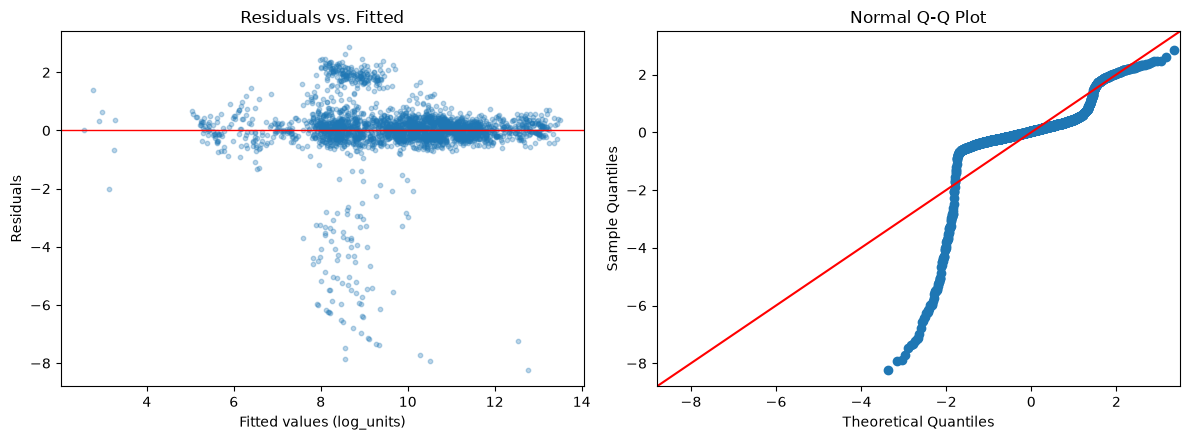

Breusch-Pagan test: stat=758.91, p=9.677e-116
Durbin-Watson: 2.416
(as in Case B, expect some autocorrelation -- each category is its own monthly time series. Worth flagging that p-values here are probably a bit optimistic; doesn't bias the point forecast itself.)


In [8]:
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import het_breuschpagan

resid = model_full.resid
fitted = model_full.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(fitted, resid, alpha=0.3, s=10)
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_xlabel("Fitted values (log_units)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted")

qqplot(resid, line="45", ax=axes[1])
axes[1].set_title("Normal Q-Q Plot")

plt.tight_layout()
plt.show()

bp_stat, bp_pvalue, _, _ = het_breuschpagan(resid, model_full.model.exog)
print(f"Breusch-Pagan test: stat={bp_stat:.2f}, p={bp_pvalue:.4g}")
print(f"Durbin-Watson: {sm.stats.stattools.durbin_watson(resid):.3f}")
print("(as in Case B, expect some autocorrelation -- each category is its own "
      "monthly time series. Worth flagging that p-values here are probably a "
      "bit optimistic; doesn't bias the point forecast itself.)")


### 3. Multicollinearity check (VIF)

Expected to run higher than Case B's, since raw weather levels correlate
with month by construction. That's an acceptable tradeoff *for this task*
(see the design note at top) as long as it isn't so extreme it destabilizes
the fitted coefficients used for forecasting.


In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_check_cols = ["avg_max_temp_f", "total_precip_in", "t", "iowa_population", "iowa_median_household_income"]
X_vif = sm.add_constant(model_df[feature_cols_full].astype(float))

vif_scores = pd.Series(
    [variance_inflation_factor(X_vif.values, X_vif.columns.get_loc(c)) for c in vif_check_cols],
    index=vif_check_cols,
    name="VIF",
)
vif_scores


avg_max_temp_f                  43.272545
total_precip_in                  3.365601
t                                6.025596
iowa_population                 23.954312
iowa_median_household_income    19.355968
Name: VIF, dtype: float64

### 4. Does it generalize? (time-based holdout)

Most recent months held out, same convention as Case B — a forecasting
model has to be judged on months it hasn't seen, not in-sample fit.


In [10]:
HOLDOUT_MONTHS = 6

all_year_months = sorted(model_df["year_month"].unique())
test_months = all_year_months[-HOLDOUT_MONTHS:]
train_mask = ~model_df["year_month"].isin(test_months)
test_mask = model_df["year_month"].isin(test_months)

print(f"Training on {train_mask.sum()} rows through {all_year_months[-HOLDOUT_MONTHS - 1]}, "
      f"testing on {test_mask.sum()} rows from {test_months[0]} to {test_months[-1]}")


def fit_and_evaluate(feature_cols, label):
    X_train = sm.add_constant(model_df.loc[train_mask, feature_cols].astype(float))
    y_train = model_df.loc[train_mask, "log_units"].astype(float)
    fitted_model = sm.OLS(y_train, X_train, missing="drop").fit()

    X_test = sm.add_constant(model_df.loc[test_mask, feature_cols].astype(float), has_constant="add")
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0.0)
    y_test = model_df.loc[test_mask, "log_units"].astype(float)
    preds = fitted_model.predict(X_test)

    rmse_log = np.sqrt(np.mean((preds - y_test) ** 2))
    mae_log = np.mean(np.abs(preds - y_test))

    actual_units = np.expm1(y_test)
    pred_units = np.expm1(preds)
    rmse_units = np.sqrt(np.mean((pred_units - actual_units) ** 2))
    mae_units = np.mean(np.abs(pred_units - actual_units))

    return {
        "label": label,
        "rmse_log": rmse_log, "mae_log": mae_log,
        "rmse_units": rmse_units, "mae_units": mae_units,
    }


results = [
    fit_and_evaluate(feature_cols_baseline, "Model A (baseline)"),
    fit_and_evaluate(feature_cols_full, "Model B (+ external data)"),
]
pd.DataFrame(results).set_index("label")


Training on 2308 rows through 2026-02, testing on 264 rows from 2026-03 to 2026-08


,rmse_log,mae_log,rmse_units,mae_units
label,,,,
Model A (baseline),0.530017,0.381066,61691.908622,23019.961864
Model B (+ external data),0.523437,0.367281,61322.244770,22729.400032


## Projecting the coming year

This is the actual client deliverable: fit the chosen model on **all**
available history, then build a feature frame for the next 12 calendar
months and predict. Future weather is unknowable, so each future month is
filled in with the **average of that calendar month's historical values**
across the panel (e.g. every July's `avg_max_temp_f` averaged together) as
a stand-in for a climatological normal -- the build notebook's raw NOAA
`climo_high_f`/`climo_precip_in` columns don't survive the monthly
aggregation into the saved parquet, so this recomputes an equivalent
in-panel normal instead of assuming those columns exist. Holidays are known
in advance from the calendar; demographics are extrapolated with a simple
linear trend off the historical annual series (documented as a simplifying
assumption, not a demographic forecast model in its own right).


In [11]:
LAST_YEAR = int(df["year"].max())
LAST_MONTH = int(df.loc[df["year"] == LAST_YEAR, "month_num"].max())
future_periods = pd.date_range(
    start=pd.Timestamp(year=LAST_YEAR, month=LAST_MONTH, day=1) + pd.offsets.MonthBegin(1),
    periods=12, freq="MS",
)

categories = df["category_name"].unique()
future_rows = []
for period in future_periods:
    for cat in categories:
        future_rows.append({
            "category_name": cat,
            "year": period.year,
            "month_num": period.month,
            "year_month": period.strftime("%Y-%m"),
        })
future_df = pd.DataFrame(future_rows)
future_df["t"] = (future_df["year"] - df["year"].min()) * 12 + future_df["month_num"]

# climatological-normal weather per calendar month, averaged across history
climo_by_month = df.groupby(df["month_num"])[["avg_max_temp_f", "total_precip_in"]].mean()
future_df = future_df.merge(climo_by_month, on="month_num", how="left")

# holidays: known in advance for real future calendar months
future_years = range(int(future_periods.min().year), int(future_periods.max().year) + 1)
future_holidays = holidays.US(state="IA", years=future_years)
fh_df = pd.DataFrame([{"date": pd.Timestamp(d), "name": n} for d, n in future_holidays.items()])
fh_df["year_month"] = fh_df["date"].dt.strftime("%Y-%m")
fh_monthly = fh_df.groupby("year_month").agg(n_holidays=("name", "count")).reset_index()
for col, pattern in {
    "has_july4": "Independence Day", "has_thanksgiving": "Thanksgiving",
    "has_christmas": "Christmas", "has_new_year": "New Year",
}.items():
    flagged = set(fh_df.loc[fh_df["name"].str.contains(pattern, case=False, na=False), "year_month"])
    fh_monthly[col] = fh_monthly["year_month"].apply(lambda ym: int(ym in flagged))
future_df = future_df.merge(fh_monthly, on="year_month", how="left").fillna(
    {"n_holidays": 0, "has_july4": 0, "has_thanksgiving": 0, "has_christmas": 0, "has_new_year": 0}
)

# demographics: simple linear extrapolation off the historical annual series
demo_hist = df[["year", "iowa_population", "iowa_median_household_income"]].drop_duplicates("year").sort_values("year")
pop_trend = np.polyfit(demo_hist["year"], demo_hist["iowa_population"], 1)
income_trend = np.polyfit(demo_hist["year"], demo_hist["iowa_median_household_income"], 1)
future_df["iowa_population"] = np.polyval(pop_trend, future_df["year"])
future_df["iowa_median_household_income"] = np.polyval(income_trend, future_df["year"])

print(future_df.shape)
future_df.head()


(612, 14)


,category_name,year,month_num,year_month,t,avg_max_temp_f,total_precip_in,n_holidays,has_july4,has_thanksgiving,has_christmas,has_new_year,iowa_population,iowa_median_household_income
0,100% AGAVE TEQUILA,2026,9,2026-09,57,79.39981,1.821811,1.0,0.0,0.0,0.0,0.0,3214841.2,75956.6
1,AGED DARK RUM,2026,9,2026-09,57,79.39981,1.821811,1.0,0.0,0.0,0.0,0.0,3214841.2,75956.6
2,AMERICAN BRANDIES,2026,9,2026-09,57,79.39981,1.821811,1.0,0.0,0.0,0.0,0.0,3214841.2,75956.6
3,AMERICAN CORDIALS & LIQUEURS,2026,9,2026-09,57,79.39981,1.821811,1.0,0.0,0.0,0.0,0.0,3214841.2,75956.6
4,AMERICAN DISTILLED SPIRITS SPECIALTY,2026,9,2026-09,57,79.39981,1.821811,1.0,0.0,0.0,0.0,0.0,3214841.2,75956.6


In [12]:
# refit Model B on ALL available history for the actual production forecast
X_all = sm.add_constant(model_df[feature_cols_full].astype(float))
model_production = sm.OLS(y, X_all, missing="drop").fit()

future_dummies = pd.get_dummies(future_df, columns=["month_num", "category_name"], drop_first=True)
X_future = sm.add_constant(future_dummies, has_constant="add")
X_future = X_future.reindex(columns=X_all.columns, fill_value=0.0)

# match the training preprocessing exactly: X_all was built via
# model_df[feature_cols_full].astype(float) before fitting. future_dummies
# never got that same explicit cast -- its dummy columns are still `bool`,
# and after reindex()'ing in the 0.0-filled columns, pandas can end up
# consolidating the whole frame into an `object`-dtype array. That silently
# breaks np.expm1 below (it tries to call .expm1() on each individual Python
# float instead of running vectorized), so force it back to a clean float64
# frame here, the same as the training matrix.
X_future = X_future.astype(float)

future_df["log_units_pred"] = model_production.predict(X_future)
future_df["units_pred"] = np.expm1(future_df["log_units_pred"])

annual_projection = future_df.groupby("category_name")["units_pred"].sum().sort_values(ascending=False)
print("Projected units, next 12 months, top categories:")
annual_projection.head(15)


Projected units, next 12 months, top categories:


category_name
AMERICAN VODKAS              6.743271e+06
WHISKEY LIQUEUR              6.234972e+06
CANADIAN WHISKIES            3.978952e+06
STRAIGHT BOURBON WHISKIES    2.347767e+06
SPICED RUM                   1.866750e+06
100% AGAVE TEQUILA           1.529478e+06
AMERICAN SCHNAPPS            1.413702e+06
AMERICAN FLAVORED VODKA      1.376282e+06
BLENDED WHISKIES             1.112582e+06
MIXTO TEQUILA                1.070824e+06
TENNESSEE WHISKIES           9.850455e+05
AMERICAN BRANDIES            9.380590e+05
COCKTAILS/RTD                7.047717e+05
FLAVORED RUM                 6.567842e+05
WHITE RUM                    6.377508e+05
Name: units_pred, dtype: float64

## Notes for the Booze 'R' Us write-up / presentation

- **Baseline vs. full model:** the nested F-test and holdout comparison
  above are the honest answer to "is the external data worth collecting at
  all" — if Model B's holdout error isn't meaningfully better than the
  baseline, that's worth saying plainly rather than overselling the
  external-data story.
- **Multicollinearity is an accepted tradeoff here, not an oversight:**
  raw weather levels are correlated with month by construction; that's fine
  for prediction (see design note at top) but means individual weather
  coefficients shouldn't be over-interpreted causally — that's Case B's job,
  not this one.
- **The 12-month projection rests on real simplifying assumptions** worth
  stating directly to the client: future weather = historical climatological
  average per month (not a real forecast), demographics = simple linear
  trend off a handful of annual points
  (not a demographic model), holidays = actual known future calendar.
  Reasonable for a "coming year" planning estimate; not a substitute for a
  proper weather/demographic forecast if the client wants tighter bounds.
- **Category-level correlations** (holiday-sensitivity, income-sensitivity)
  are the starting point for the "adjust sales tactics" / "where to expand"
  half of the ask — worth pairing with a confidence interval or holdout
  check per category before making a specific tactical recommendation, since
  some categories will have thin per-month sample sizes.
